In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
sns.set_style('whitegrid')
sns.set_palette("Set2")

%matplotlib inline

# Leer los datos

In [3]:
df_fe = pd.read_csv("../../data/respuestas_fede.csv")
print(df_fe.shape)

#globales
marmol = df_fe.loc[df_fe["escuela"] == "Colegio Modelo Mármol"]
mantovani = df_fe.loc[df_fe["escuela"] == "Escuela Nueva Juan Mantovani"]
cant_total = len(df_fe)
cant_marmol = len(marmol)
cant_mantovani = len(mantovani)
# genero
cant_marmol_masc = len(marmol[marmol['genero']=="Masculino"])
cant_marmol_fem = len(marmol[marmol['genero']=="Femenino"])
cant_mantovani_masc = len(mantovani[mantovani['genero']=="Masculino"])
cant_mantovani_fem = len(mantovani[mantovani['genero']=="Femenino"])
# grados
cant_marmol_quinto = len(marmol[marmol['grado']=="Quinto"])
cant_marmol_sexto = len(marmol[marmol['grado']=="Sexto"])
cant_mantovani_cuarto = len(mantovani[mantovani['grado']=="Cuarto"])
cant_mantovani_quinto = len(mantovani[mantovani['grado']=="Quinto"])
cant_mantovani_sexto = len(mantovani[mantovani['grado']=="Sexto"])

(369, 22)


# Data Fede, features como filas 

In [6]:
df_fe.head().transpose()

,0,1,2,3,4
timestamp,11/17/2022 8:35:00,11/17/2022 8:36:12,11/17/2022 8:36:21,11/17/2022 8:36:30,11/17/2022 8:36:39
escuela,Escuela Nueva Juan Mantovani,Escuela Nueva Juan Mantovani,Escuela Nueva Juan Mantovani,Escuela Nueva Juan Mantovani,Escuela Nueva Juan Mantovani
grado,Quinto,Quinto,Quinto,Quinto,Quinto
curso,B,B,B,B,B
edad,10,10,11,10,11
genero,Masculino,Masculino,Masculino,Masculino,Femenino
lugar_computadora,En la escuela,En mi casa,En mi casa,En mi casa,En mi casa
uso_computadora,"Juego juegos, Hago la tarea","Juego juegos, Miro videos en YouTube",Juego juegos,"Juego juegos, Hablo con amigos",Hablo con amigos
aprender_computadora,Me enseñaron en mi casa,Me enseñaron en mi casa,Aprendí solo,Me enseñaron en mi casa,"Me enseñaron en mi casa, Aprendí solo"
dueño_celular,El mío,El mío,El mío,El mío,El mío


# Descripción del grupo

A continuación se describe el grupo encuestado según distintas variables poblacionales. 

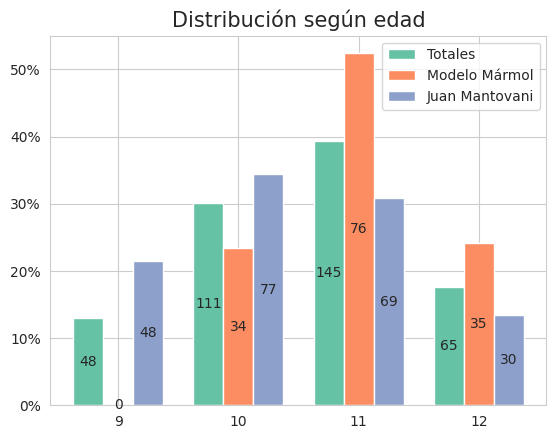

In [39]:
# Distribución según edad
dfs = [df["edad"].value_counts() for df in [df_fe, marmol, mantovani]]
result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 
                                1: "Modelo Mármol", 
                                2: "Juan Mantovani"}
                                ).fillna(0).astype('Int64')

cantidades = [ result["Totales"].to_numpy(),
               result["Modelo Mármol"].to_numpy(), 
               result["Juan Mantovani"].to_numpy()]

fig, ax = plt.subplots()

bar_width = 0.25
br1 = np.arange(len(result["Totales"]))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result["Totales"].div(cant_total)            , width=bar_width, label = 'Totales')
plt.bar(br2,result["Modelo Mármol"].div(cant_marmol)     , width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result["Juan Mantovani"].div(cant_mantovani) , width=bar_width, label = 'Juan Mantovani')

i = 0
for bars in ax.containers:
    ax.bar_label(bars, labels=cantidades[i], label_type="center")
    i=i+1

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución según edad", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('edad.png')

* Los números en las columnas son cantidades de niñes por edad.
* Los porcentajes son en base a cantidades totales por colegio.
* No hay chicas/os de 9 años en el Modelo Mármol. Tiene sentido pues no tenemos chiques de cuarto grado.
* Hay poco más del doble de niñes de 10 años en el Mantovani que el Modelo. Tiene sentido pues la mitad de los chicos de Cuarto grado tienen 10 años.
* Las cantidades de chicos y chicas de 11 y 12 años están similarmente distribuidas.

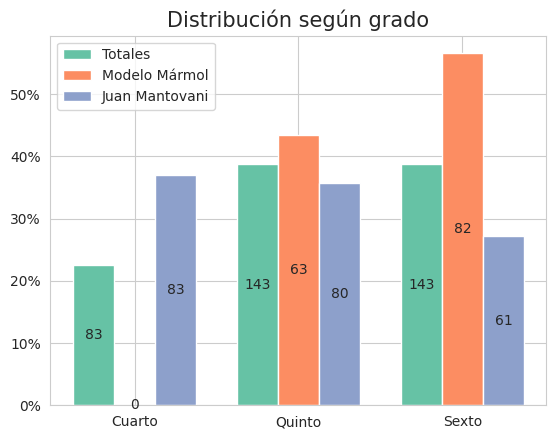

In [52]:
# # Distribución según grado
dfs = [df["grado"].value_counts() for df in [df_fe, marmol, mantovani]]
result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 
                                1: "Modelo Mármol", 
                                2: "Juan Mantovani"}
                                ).fillna(0).astype('Int64').sort_index()

cantidades = [ result["Totales"].to_numpy(),
               result["Modelo Mármol"].to_numpy(), 
               result["Juan Mantovani"].to_numpy()]

bar_width = 0.25
br1 = np.arange(len(result["Totales"]))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

fig, ax = plt.subplots()

plt.bar(br1,result["Totales"].div(cant_total)           , width=bar_width, label = 'Totales')
plt.bar(br2,result["Modelo Mármol"].div(cant_marmol)    , width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result["Juan Mantovani"].div(cant_mantovani), width=bar_width, label = 'Juan Mantovani')

i = 0
for bars in ax.containers:
    ax.bar_label(bars, labels=cantidades[i], label_type="center")
    i=i+1

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución según grado", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()

plt.savefig('grado.png')

* Los números en las columnas son cantidades de niñes por grado.
* Los porcentajes son del total de alumnos encuestados.
* Alumnas/os de quinto y sexto similarmente distribuidos.
* No tenemos alumnas/os en cuarto grado en el Modelo Mármol.
* Cantidad similar de alumnas/os de cuarto grado a los quintos y sextos.

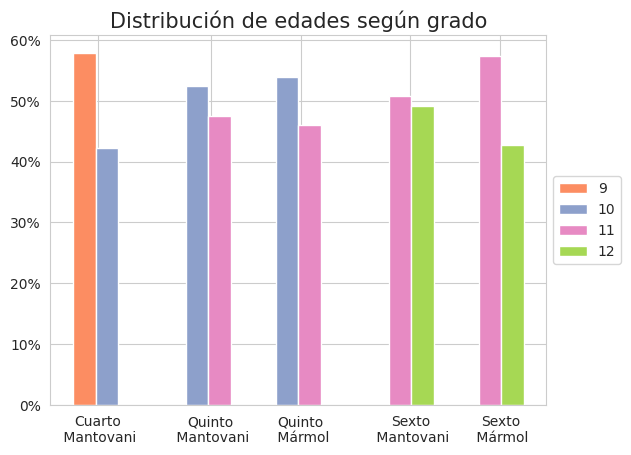

In [54]:
# Distribución de edades según grado

dfs_marmol    = [marmol   [marmol   ['grado']==grado]["edad"].value_counts(normalize=True) for grado in [          "Quinto", "Sexto"]]
dfs_mantovani = [mantovani[mantovani['grado']==grado]["edad"].value_counts(normalize=True) for grado in ["Cuarto", "Quinto", "Sexto"]]

result = pd.concat(dfs_marmol + dfs_mantovani, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto\n Mármol',
                                1:'Sexto\n Mármol',
                                2:'Cuarto\n Mantovani',
                                3:'Quinto\n Mantovani',
                                4:'Sexto\n Mantovani'}).fillna(0)
bar_width = 0.25
result = result.transpose()

result = result.reindex(['Cuarto\n Mantovani',
                         'Quinto\n Mantovani',
                         'Quinto\n Mármol',
                         'Sexto\n Mantovani',
                         'Sexto\n Mármol'])

br1 = np.arange(len(result[9]))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]
br4 = [x + bar_width for x in br3]

plt.bar(br1, result[9] ,  width=bar_width, label = '9', color='C1')
plt.bar(br2, result[10],  width=bar_width, label = '10', color='C2')
plt.bar(br3, result[11],  width=bar_width, label = '11', color='C3')
plt.bar(br4, result[12],  width=bar_width, label = '12', color='C4')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución de edades según grado", fontsize=15)
plt.xticks([0.15, 1.4, 2.4, 3.615, 4.615], result.index)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('edades_segun_grado.png')

* Los porcentajes son en base a total de alumnos/as por Grado y por Colegio.
* Para participantes de cuarto grado solo hay datos del Mantovani. Sus edades están distribuídas entre 9 y 10 entre 40% y 60%
* En quinto grado las edades están casi igualmente distribuídas en ambos colegios. Ambos tienen casi un 50% entre 10 y 11 años.
* En sexto grado las edades están casi igualmente distribuidas en el Mantovani. En el Modelo Mármol vemos un 57% con 11 años y un 43% con 12 años.

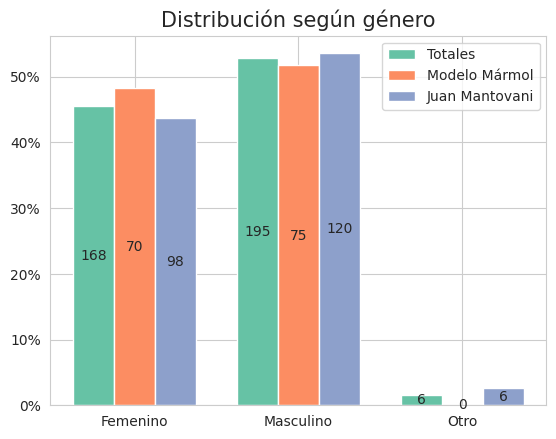

In [55]:
# # Distribución según género
dfs = [df["genero"].value_counts() for df in [df_fe, marmol, mantovani]]
result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 
                                1: "Modelo Mármol", 
                                2: "Juan Mantovani"}
                                ).fillna(0).astype('Int64').sort_index()

cantidades = [ result["Totales"].to_numpy(),
               result["Modelo Mármol"].to_numpy(), 
               result["Juan Mantovani"].to_numpy()]

bar_width = 0.25
br1 = np.arange(len(result["Totales"]))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

fig, ax = plt.subplots()

plt.bar(br1,result["Totales"].div(cant_total)           , width=bar_width, label = 'Totales')
plt.bar(br2,result["Modelo Mármol"].div(cant_marmol)    , width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result["Juan Mantovani"].div(cant_mantovani), width=bar_width, label = 'Juan Mantovani')

i = 0
for bars in ax.containers:
    ax.bar_label(bars, labels=cantidades[i], label_type="center")
    i=i+1

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución según género", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()

plt.savefig('genero.png')

* Los porcentajes son sobre datos por colegio.
* En ambos colegios están bien distribuídos, en el Modelo Mármol un tanto mejor que en el Mantovani.

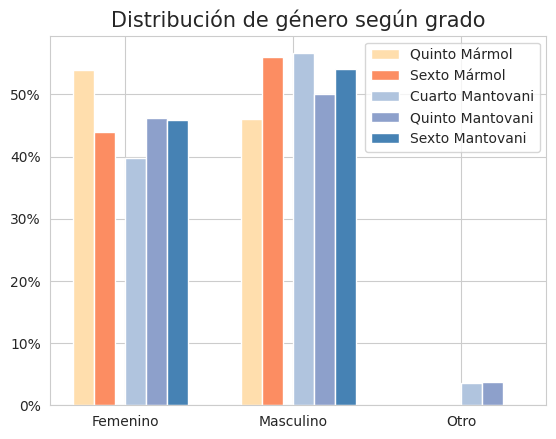

In [57]:
# Distribución de genero según grado 
dfs_marmol    = [marmol   [marmol   ['grado']==grado]["genero"].value_counts(normalize=True) for grado in [          "Quinto", "Sexto"]]
dfs_mantovani = [mantovani[mantovani['grado']==grado]["genero"].value_counts(normalize=True) for grado in ["Cuarto", "Quinto", "Sexto"]]

result = pd.concat(dfs_marmol + dfs_mantovani, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto\n Mármol',
                                1:'Sexto\n Mármol',
                                2:'Cuarto\n Mantovani',
                                3:'Quinto\n Mantovani',
                                4:'Sexto\n Mantovani'}).fillna(0)
bar_width = 0.25

br1 = [1, 3, 5]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto\n Mármol']    , width=bar_width, label = 'Quinto Mármol'    , color='navajowhite'   )
plt.bar(br2, result['Sexto\n Mármol']     , width=bar_width, label = 'Sexto Mármol'     , color='C1'            )
plt.bar(br3, result['Cuarto\n Mantovani'] , width=bar_width, label = 'Cuarto Mantovani' , color='lightsteelblue')
plt.bar(br4, result['Quinto\n Mantovani'] , width=bar_width, label = 'Quinto Mantovani' , color='C2'            )
plt.bar(br5, result['Sexto\n Mantovani']  , width=bar_width, label = 'Sexto Mantovani'  , color='steelblue'     )

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución de género según grado", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('genero_segun_grado.png')

* Los porcentajes son sobre la cantidad total de alumnos por grado
* El cuarto grado del Mantovani tiene una distribución mayor de varones que mujeres, un 60-40.
* Quinto y Sexto de ambos colegios tienen una distribución de entre 45-55 por lo que están bien distribuídos.
* El género Otro no tiene grandes porcentajes en ningún grado.

# Lugar de uso de la Computadora

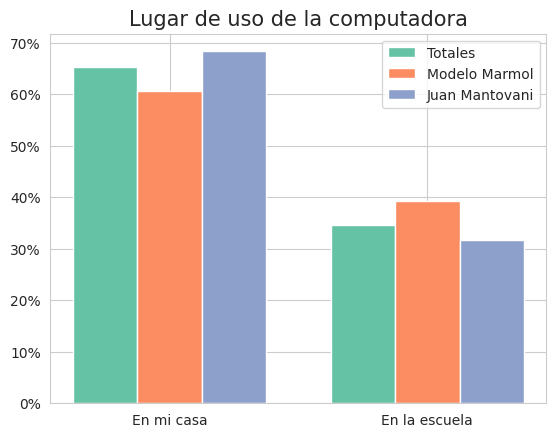

In [70]:
# Lugar de uso de la computadora
dfs = [df["lugar_computadora"].value_counts() for df in [df_fe, marmol, mantovani]]
result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 
                                1: "Modelo Mármol", 
                                2: "Juan Mantovani"}
                                ).fillna(0)

bar_width = 0.25
br1 = np.arange(len(result["Totales"]))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

fig, ax = plt.subplots()

plt.bar(br1,result["Totales"].div(cant_total)           , width=bar_width, label = 'Totales')
plt.bar(br2,result["Modelo Mármol"].div(cant_marmol)    , width=bar_width, label = 'Modelo Marmol')
plt.bar(br3,result["Juan Mantovani"].div(cant_mantovani), width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Lugar de uso de la computadora", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()

plt.savefig('lugar_uso_computadora.png')

* Los porcentajes son sobre datos por colegio.
* En el Modelo Mármol al rededor de un 40% usa la computadora en la escuela y un 60% en la casa.
* En el Juan Mantovani cerca de un 30% usa la computadora en la escuela y un 70% en la casa.

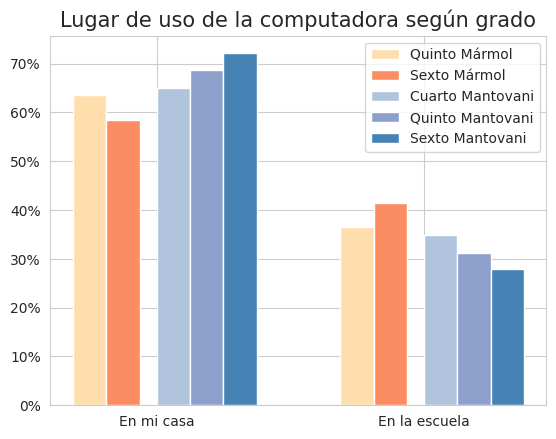

In [72]:
# Lugar de uso de la compu según grado
dfs_marmol    = [marmol   [marmol   ['grado']==grado]["lugar_computadora"].value_counts(normalize=True) for grado in [          "Quinto", "Sexto"]]
dfs_mantovani = [mantovani[mantovani['grado']==grado]["lugar_computadora"].value_counts(normalize=True) for grado in ["Cuarto", "Quinto", "Sexto"]]

result = pd.concat(dfs_marmol + dfs_mantovani, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto\n Mármol',
                                1:'Sexto\n Mármol',
                                2:'Cuarto\n Mantovani',
                                3:'Quinto\n Mantovani',
                                4:'Sexto\n Mantovani'}).fillna(0)

bar_width = 0.25

br1 = [1,3]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto\n Mármol']    , width=bar_width, label = 'Quinto Mármol'    , color='navajowhite'   )
plt.bar(br2, result['Sexto\n Mármol']     , width=bar_width, label = 'Sexto Mármol'     , color='C1'            )
plt.bar(br3, result['Cuarto\n Mantovani'] , width=bar_width, label = 'Cuarto Mantovani' , color='lightsteelblue')
plt.bar(br4, result['Quinto\n Mantovani'] , width=bar_width, label = 'Quinto Mantovani' , color='C2'            )
plt.bar(br5, result['Sexto\n Mantovani']  , width=bar_width, label = 'Sexto Mantovani'  , color='steelblue'     )

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Lugar de uso de la computadora según grado", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('lugar_uso_computadora_segun_grado.png')

* Los porcentajes son en base a los totales por grado.
* En el modelo Modelo Mármol, tanto para quinto y sexto grado, los porcentajes que usan la computadora en la escuela mayormente, son serca de un 40%. Este porcentaje se incrementa desde Quinto a Sexto.
* En el Juan Mantovani, el porcentaje de alumnos que usa la computadora en la escuela mayormente ronda el 30% y decrece a medida que nos movemos entre las muestras desde Cuarto hasta Sexto grado.

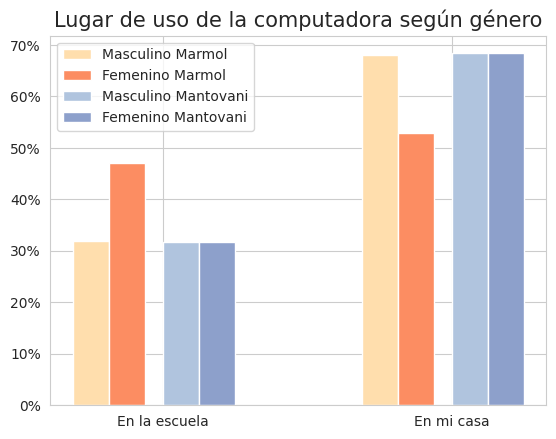

In [15]:
# lugar de uso de la compu según genero
data_total = df_fe["lugar_computadora"].value_counts().sort_index()

data_marmol_mas = marmol[marmol['genero']=="Masculino"]["lugar_computadora"].value_counts(normalize=True).sort_index()
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["lugar_computadora"].value_counts(normalize=True).sort_index()
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["lugar_computadora"].value_counts(normalize=True).sort_index()
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["lugar_computadora"].value_counts(normalize=True).sort_index()

dfs = [data_marmol_mas, data_marmol_fem, data_mantovani_mas, data_mantovani_fem]

for data in data_total.index:
    for df in dfs:
        if data not in df.index:
            df[data] = 0.0
        df = df.sort_index()

bar_width = 0.25
ticks = [1, 3]
br1 = ticks
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

br4 = [x + 1.5*bar_width for x in br3]
br5 = [x + bar_width for x in br4]

plt.bar(br2,dfs[0], width=bar_width, label = 'Masculino Marmol', color='navajowhite')
plt.bar(br3,dfs[1], width=bar_width, label = 'Femenino Marmol', color='C1')
plt.bar(br4,dfs[2], width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br5,dfs[3], width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Lugar de uso de la computadora según género", fontsize=15)
ticks = [x + 3*bar_width for x in ticks]
plt.xticks(ticks, [id for id in data_total.sort_index().index])
plt.legend()
plt.savefig('lugar_uso_computadora_segun_genero.png')

* Los porcentajes son sobre totales por género
* En el Modelo Mármol los varones usan menos la computadora en la escuela y más en su casa.
* En el Mantovani están igualados en lugar de uso en cuanto a género.
* Se quitó el género otro pues eran apenas 6 personas y no era una muestra significativa.

# Uso de la computadora

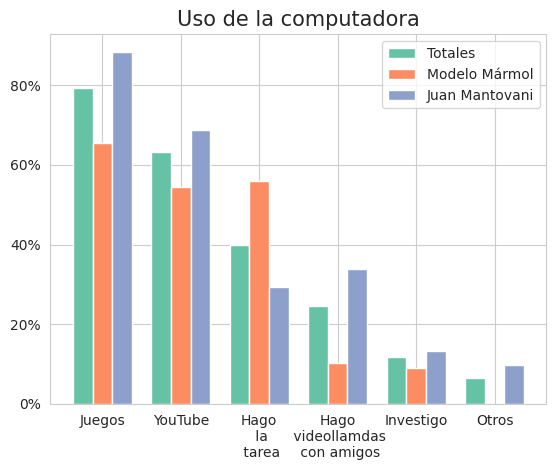

In [104]:
# Uso de la computadora
data_total = df_fe["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)
data_marmol = marmol["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol).sort_values(ascending=False)
data_mantovani = mantovani["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani).sort_values(ascending=False)

otros = ["Programo/Diseño", "Usoredessociales", "MiroPelis/Seriesporstreaming", "Escuchomúsica"]

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"})
result.loc["Otros"] = [0.0]*3

for row in otros:
        result.loc['Otros'] += result.loc[row]
        result.drop([row], inplace=True)

bar_width = 0.25

br1 = np.arange(len(result))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

labels = ("Juegos", "YouTube", "Hago\n la\n tarea", \
            "Hago\n videollamdas\n con amigos", "Investigo", "Otros")

plt.bar(br1,result["Totales"]       , width=bar_width, label = 'Totales')
plt.bar(br2,result["Modelo Mármol"] , width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result["Juan Mantovani"], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Uso de la computadora", fontsize=15)
ticks = [x + bar_width for x in br1]
plt.xticks(ticks, labels)
plt.legend(loc='upper right')
plt.savefig('uso_computadora.png')

* Los porcentajes son por totales por colegio.
* En esta pregunta se permitían seleccionar varias respuestas.
* En la opción de Investigo se agruparon las respuestas de "Leo artículos en Wikipedia" con otras respuestas de chicos que buscaban información en internet.
* La respuesta "Otros" acumula las respuestas "Programo/Diseño", "Usoredessociales", "MiroPelis/Seriesporstreaming", "Escuchomúsica" que eran seleccionadas menos del 10% de las veces por los chicos.
* En el Modelo Mármol, Jugar videojuegos, Ver videos en Youtube, Hacer la tarea son las opciones más elegidas con cerca de un 60% de los chicos seleccionándolas. Videollamadas e Investigar están por debajo del 10%
* En el Mantovani Jugar Juegos y Youtube son seleccionadas más del 70% de las veces. Hacer la tarea y videollamadas cerca de un 30%.
* Al compararlos vemos que en el Mantovani se selecciona más Jugar Juegos y hacer videollamadas. En el Modelo, se selecciona más Hago la tarea. También vemos que en Mantovani las respuestas están más esparcidas y no tan concentradas en Juegos, Youtube y Tarea.

In [87]:
# Promedio en cantidad de respuestas - Uso computadora
data_total = df_fe["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_marmol = marmol["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani = mantovani["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()

dfs = [data_total, data_marmol, data_mantovani]
labels = ['Totales','Modelo Mármol','Juan Mantovani']

result = pd.DataFrame(data=[dfs], columns=labels)
print("Promedio en cantidad de respuestas - Uso computadora")
result.head()

Promedio en cantidad de respuestas - Uso computadora


,Totales,Modelo Mármol,Juan Mantovani
0,2.252033,1.965517,2.4375


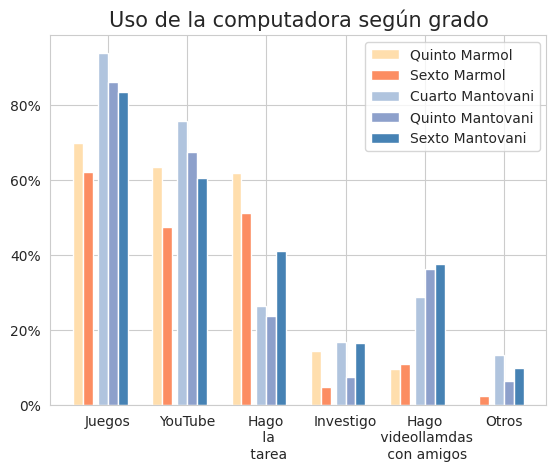

In [17]:
# Uso de la computadora según grado
data_total = df_fe["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)

data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol_quinto).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol_sexto).sort_values(ascending=False)

data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_cuarto).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_quinto).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_sexto).sort_values(ascending=False)

otros = ["Programo/Diseño", "Usoredessociales", "MiroPelis/Seriesporstreaming", "Escuchomúsica"]

dfs = [data_marmol_quinto, data_marmol_sexto, data_mantovani_cuarto, data_mantovani_quinto, data_mantovani_sexto]

result = pd.concat(dfs, axis=1)
result = result.rename(columns={0:'Quinto Marmol',
                                1:'Sexto Marmol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'})

result.loc["Otros"] = [0.0]*5

result =result.fillna(0)

for row in otros:
        result.loc['Otros'] += result.loc[row]
        result.drop([row], inplace=True)

bar_width = 0.25

ticks = [1, 3, 5, 7, 9, 11]

labels = ("Juegos", "YouTube", "Hago\n la\n tarea", \
            "Investigo", "Hago\n videollamdas\n con amigos", "Otros")

br_marmol_quinto = ticks
br_marmol_sexto = [x + bar_width for x in br_marmol_quinto]

br_mantovani_cuarto = [x + 1.5* bar_width for x in br_marmol_sexto]
br_mantovani_quinto = [x + bar_width for x in br_mantovani_cuarto]
br_mantovani_sexto  = [x + bar_width for x in br_mantovani_quinto]

plt.bar(br_marmol_quinto,    result['Quinto Marmol']    , width=bar_width, label = 'Quinto Marmol', color='navajowhite')
plt.bar(br_marmol_sexto,     result['Sexto Marmol']     , width=bar_width, label = 'Sexto Marmol', color='C1')
plt.bar(br_mantovani_cuarto, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br_mantovani_quinto, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br_mantovani_sexto,  result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Uso de la computadora según grado", fontsize=15)
ticks = [x + 3*bar_width for x in ticks]
plt.xticks(ticks, labels)
plt.legend(loc='upper right')
plt.savefig('uso_computadora_segun_grado.png')

* Los porcentajes son en base a totales por colegio, por grados. Son el porcentaje de alumnes de cada grado que elige esa opción.
* En esta pregunta se permitían seleccionar varias respuestas.
* Las opciones de Investigo y otros son iguales que en la pregunta anterior.
* En el Modelo Mármol, Quinto grado elige más de un 10% más las opciones Jugar, Mirar youtube Hacer la tarea e Investigar que Sexto grado.
* En el Mantovani Jugar juegos y Youtube bajan en porcentaje desde Cuarto a Sexto. Hacer la tarea sube considerablemente en Sexto. Hacer videollamadas sube grado a grado.
* Comparándolos, Jugar Juegos y Youtube se eligen más en el Mantovani en los quintos y sextos, los cambios desde cuarto a quinto son iguales. Hacer la tarea es elegida menos en el Mantovani grado a grado y aumenta de quinto a sexto.

In [100]:
# Promedio en cantidad de respuestas - Uso computadora por grado
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]
labels = ['Marmol Quinto', 'Marmol Sexto', 'Mantovani Cuarto','Mantovani Quinto', 'Mantovani Sexto']

result = pd.DataFrame(data=[dfs], columns=labels)
print("Promedio en cantidad de respuestas - Uso computadora por grado")
result.head()

Promedio en cantidad de respuestas - Uso computadora por grado


,Marmol Quinto,Marmol Sexto,Mantovani Cuarto,Mantovani Quinto,Mantovani Sexto
0,2.190476,1.792683,2.554217,2.275,2.491803


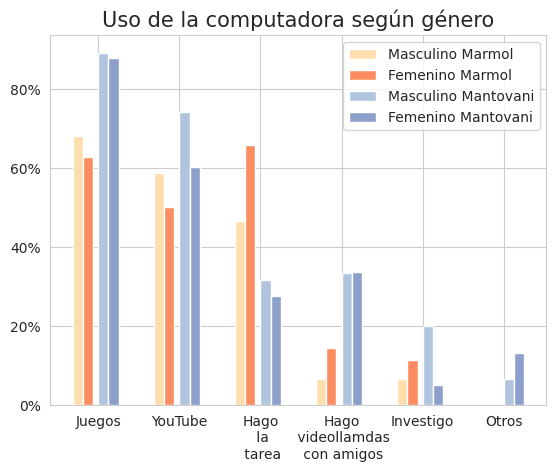

In [28]:
# Uso de la compu segun género
data_total = df_fe["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)

data_marmol_mas = marmol[marmol['genero']=="Masculino"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol_masc).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol_fem).sort_values(ascending=False)

data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_masc).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_fem).sort_values(ascending=False)

dfs = [data_marmol_mas, data_marmol_fem, data_mantovani_mas, data_mantovani_fem]

result = pd.concat(dfs, axis=1)
result = result.rename(columns={0: "Masculino Marmol", 1: "Femenino Marmol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"})
result.loc["Otros"] = [0.0]*4

otros = ["Programo/Diseño", "Usoredessociales", "MiroPelis/Seriesporstreaming", "Escuchomúsica"]

for row in otros:
        result.loc['Otros'] += result.loc[row]
        result.drop([row], inplace=True)

bar_width = 0.25

ticks = [1, 3, 5, 7, 9, 11]

labels = ("Juegos", "YouTube", "Hago\n la\n tarea", \
            "Hago\n videollamdas\n con amigos", "Investigo", "Otros")

br1 = ticks
br2 = [x + bar_width for x in br1]

br3 = [x + 1.5*bar_width for x in br2]
br4 = [x + bar_width for x in br3]

plt.bar(br1,result["Masculino Marmol"], width=bar_width, label = 'Masculino Marmol', color='navajowhite')
plt.bar(br2,result["Femenino Marmol"], width=bar_width, label = 'Femenino Marmol', color='C1')
plt.bar(br3,result["Masculino Mantovani"], width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"], width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.title("Uso de la computadora según género", fontsize=15)
ticks = [x + 2*bar_width for x in ticks]
plt.xticks(ticks, labels)
plt.legend(loc='upper right')
plt.savefig('uso_computadora_segun_genero.png')

* Los porcentajes son en base a totales por colegio, por genero. Son porcentajes totales de cada género que elige esa opción.
* En esta pregunta se permitían seleccionar varias respuestas.
* Las opciones de Investigo y otros son iguales que en la pregunta anterior.
* En el Modelo Mármol los chicos eligen un 5% más la opción de "Ver videos en Youtube". Las chicas por su parte eligen un 20% más la opción de "Hago la Tarea" y un 5% más la de "Hago videollamadas"
* En el Mantovani los chicos eligen un 15% la opción de Youtube y un 15% más la de "Investigo"
* Parecería que a grandes rasgos, en el Mantovani se seleccionan más opciones mientras que en el Modelo Mármol se centran en menos respuestas.

In [102]:
# Promedio en cantidad de respuestas - Uso computadora por género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]
labels = ['Masculino Marmol', 'Femenino Marmol', 'Masculino Mantovani','Femenino Mantovani']

result = pd.DataFrame(data=[dfs], columns=labels)
print("Promedio en cantidad de respuestas - Uso computadora por género")
result.head()

Promedio en cantidad de respuestas - Uso computadora por género


,Masculino Marmol,Femenino Marmol,Masculino Mantovani,Femenino Mantovani
0,1.88,2.057143,2.55,2.27551


# Dónde aprendieron a usar la computadora

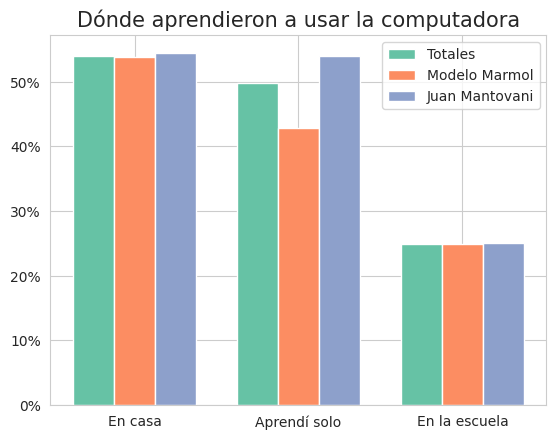

In [19]:
# Donde aprendiste a usar la computadora
data_total = df_fe["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)
data_marmol = marmol["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol).sort_values(ascending=False)
data_mantovani = mantovani["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani).sort_values(ascending=False)

for data in data_total.index:
    if data not in data_marmol.index:
        data_marmol[data] = 0.0
    if data not in data_mantovani.index:
        data_mantovani[data] = 0.0

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

labels = ("En casa", "Aprendí solo", "En la escuela")

plt.bar(br1,data_total, width=bar_width, label = 'Totales')
plt.bar(br2,data_marmol, width=bar_width, label = 'Modelo Marmol')
plt.bar(br3,data_mantovani, width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Dónde aprendieron a usar la computadora", fontsize=15)
plt.xticks([r + bar_width for r in range(len(data_total))], labels)
plt.legend()
plt.savefig('donde_aprendieron_computadora.png')

* Porcentajes sobre totales por colegio
* Se podían seleccionar varias opciones
* La opción de la escuela es la menos elegida. El resto tiene casi el mismo porcentaje de seleccion.

In [106]:
# Promedio en cantidad de respuestas - Dónde aprendieron a usar la computadora
data_total = df_fe["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_marmol = marmol["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani = mantovani["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()

dfs = [data_total,data_marmol,data_mantovani]
labels = ['Totales', 'Modelo Marmol','Juan Mantovani']

result = pd.DataFrame(data=[dfs], columns=labels)
print("Promedio en cantidad de respuestas - Dónde aprendieron a usar la computadora")
result.head()

Promedio en cantidad de respuestas - Dónde aprendieron a usar la computadora


,Totales,Modelo Marmol,Juan Mantovani
0,1.287263,1.213793,1.334821


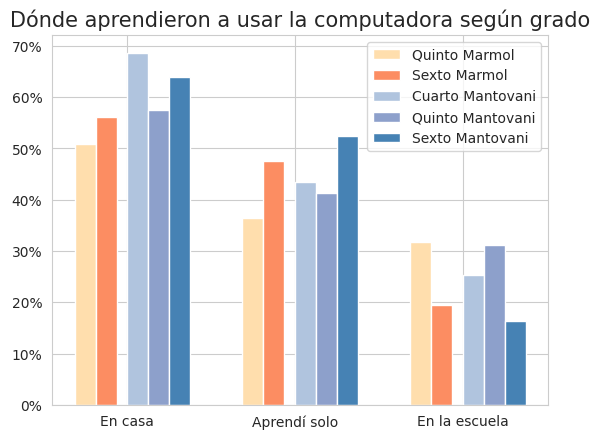

In [20]:
# Donde aprendieron a usar la computadora segun grado
data_total = df_fe["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)

data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol_quinto).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol_sexto).sort_values(ascending=False)

data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_cuarto).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_quinto).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_sexto).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

for df in dfs:
    for data in data_total.index:
        if data not in df.index:
            df[data] = 0.0

bar_width = 0.25

ticks = [1, 3, 5]

labels = ("En casa", "Aprendí solo", "En la escuela")

br_marmol_quinto = ticks
br_marmol_sexto = [x + bar_width for x in br_marmol_quinto]

br_mantovani_cuarto = [x + 1.5* bar_width for x in br_marmol_sexto]
br_mantovani_quinto = [x + bar_width for x in br_mantovani_cuarto]
br_mantovani_sexto  = [x + bar_width for x in br_mantovani_quinto]

plt.bar(br_marmol_quinto,data_marmol_quinto, width=bar_width, label = 'Quinto Marmol', color='navajowhite')
plt.bar(br_marmol_sexto,data_marmol_sexto, width=bar_width, label = 'Sexto Marmol', color='C1')
plt.bar(br_mantovani_cuarto,data_mantovani_cuarto, width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br_mantovani_quinto,data_mantovani_quinto, width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br_mantovani_sexto,data_mantovani_sexto, width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Dónde aprendieron a usar la computadora según grado", fontsize=15)
ticks = [x + 2*bar_width for x in ticks]
plt.xticks(ticks, labels)
plt.legend()
plt.savefig('donde_aprendieron_computadora_segun_grado.png')

* Porcentajes sobre cantidad total por grado.
* Varias respuestas posibles
* Para ambos colegios, quinto grado seleccionó menos veces en casa que sexto. Cuarto del Mantovani es el que más seleccionó en casa.
* Aprendí solo es la más seleccionada en ambos sextos grados.
* Los más grandes también son los que menos eligen en la escuela.

In [109]:
# Promedio en cantidad de respuestas - Dónde aprendieron a usar la computadora según grado
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]
labels = ['Quinto Marmol','Sexto Marmol','Cuarto Mantovani','Quinto Mantovani','Sexto Mantovani']

result = pd.DataFrame(data=[dfs], columns=labels)
print("Promedio en cantidad de respuestas - Dónde aprendieron a usar la computadora según grado")
result.head()

Promedio en cantidad de respuestas - Dónde aprendieron a usar la computadora según grado


,Quinto Marmol,Sexto Marmol,Cuarto Mantovani,Quinto Mantovani,Sexto Mantovani
0,1.190476,1.231707,1.373494,1.3,1.327869


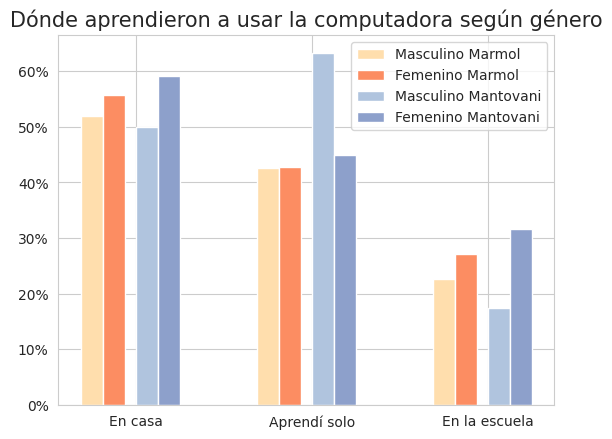

In [21]:
# Dónde aprendieron a usar la computadora según género
data_total = df_fe["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)

data_marmol_mas = marmol[marmol['genero']=="Masculino"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol_masc).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol_fem).sort_values(ascending=False)

data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_masc).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_fem).sort_values(ascending=False)

dfs = [data_marmol_mas, data_marmol_fem, data_mantovani_mas, data_mantovani_fem]

result = pd.concat(dfs, axis=1)
result = result.rename(columns={0: "Masculino Marmol", 1: "Femenino Marmol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"})

bar_width = 0.25

ticks = [1, 3, 5]

labels = ("En casa", "Aprendí solo", "En la escuela")
br1 = ticks
br2 = [x + bar_width for x in br1]

br3 = [x + 1.5*bar_width for x in br2]
br4 = [x + bar_width for x in br3]

plt.bar(br1,result["Masculino Marmol"], width=bar_width, label = 'Masculino Marmol', color='navajowhite')
plt.bar(br2,result["Femenino Marmol"], width=bar_width, label = 'Femenino Marmol', color='C1')
plt.bar(br3,result["Masculino Mantovani"], width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"], width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.title("Dónde aprendieron a usar la computadora según género", fontsize=15)
ticks = [x + 2*bar_width for x in ticks]
plt.xticks(ticks, labels)
plt.legend(loc='upper right')
plt.savefig('donde_aprendieron_computadora_segun_genero.png')

* Porcentajes sobre totales por género por colegio. Son el porcentaje del género que eligió esa opción.
* En esta pregunta se admitían múltiples respuestas.
* El genero "Otro" se quitó pues no había una muestra significante del mismo (sólo 6 alumnos)
* En el Modelo Mármol las chicas eligen un 5% más la opción "Aprendí en la escuela"
* En el Mantovani las chicas eligen la opción "Aprendí en casa" un 10% más y la opción "En la escuela" un 15% más. Los chicos por su cuenta, eligen la opción "Aprendí solo" un 20% más.

In [111]:
# Promedio en cantidad de respuestas - Dónde aprendieron a usar la computadora según género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]
labels = ['Masculino Marmol','Femenino Marmol','Masculino Mantovani','Femenino Mantovani']

result = pd.DataFrame(data=[dfs], columns=labels)
print("Promedio en cantidad de respuestas - Dónde aprendieron a usar la computadora según género")
result.head()

Promedio en cantidad de respuestas - Dónde aprendieron a usar la computadora según género


,Masculino Marmol,Femenino Marmol,Masculino Mantovani,Femenino Mantovani
0,1.173333,1.257143,1.308333,1.357143


# Dueño del celular

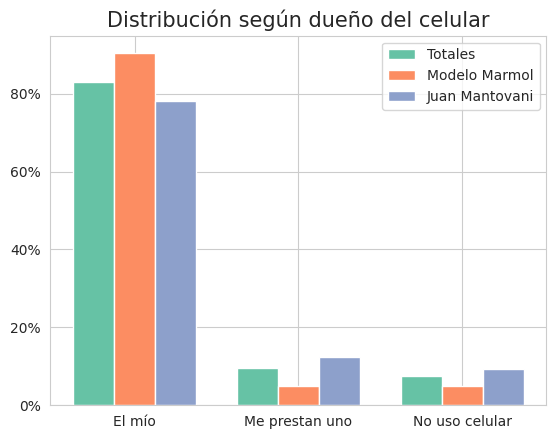

In [22]:
# Distribución según dueño del celular
data_total = df_fe["dueño_celular"].value_counts(normalize=True).sort_index()
data_marmol = marmol["dueño_celular"].value_counts(normalize=True).sort_index()
data_mantovani = mantovani["dueño_celular"].value_counts(normalize=True).sort_index()

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,data_total, width=bar_width, label = 'Totales')
plt.bar(br2,data_marmol, width=bar_width, label = 'Modelo Marmol')
plt.bar(br3,data_mantovani, width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución según dueño del celular", fontsize=15)
plt.xticks([r + bar_width for r in range(len(data_total))], [id for id in data_total.sort_index().index])
plt.legend()
plt.savefig('dueño_celular.png')

* Porcentajes sobre totales por colegio
* La gran mayoría tiene celular propio en ambos colegios

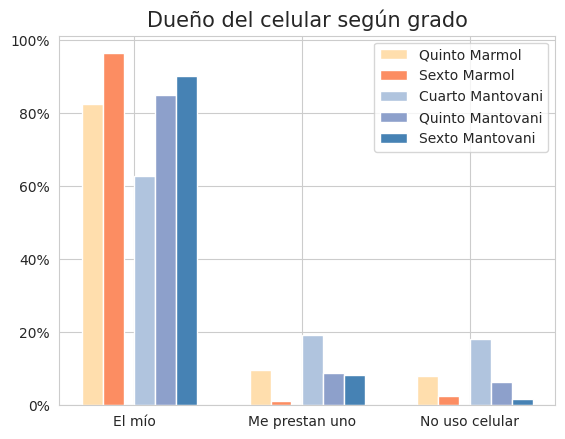

In [23]:
# Dueño del celular según grado
data_total = df_fe["dueño_celular"].value_counts(normalize=True).sort_index()

data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["dueño_celular"].value_counts(normalize=True).sort_index()
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["dueño_celular"].value_counts(normalize=True).sort_index()

data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["dueño_celular"].value_counts(normalize=True).sort_index()
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["dueño_celular"].value_counts(normalize=True).sort_index()
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["dueño_celular"].value_counts(normalize=True).sort_index()

dfs = [data_marmol_quinto, data_marmol_sexto, data_mantovani_cuarto, data_mantovani_quinto, data_mantovani_sexto]

for df in dfs:
    for data in data_total.index:
        if data not in df.index:
            df[data] = 0.0
    df = df.sort_index()

bar_width = 0.25
ticks = [1, 3, 5]

br2 = [x + bar_width for x in ticks]
br3 = [x + bar_width for x in br2]

br4 = [x + 1.5*bar_width for x in br3]
br5 = [x + bar_width for x in br4]
br6 = [x + bar_width for x in br5]

plt.bar(br2,data_marmol_quinto, width=bar_width, label = 'Quinto Marmol', color='navajowhite')
plt.bar(br3,data_marmol_sexto, width=bar_width, label = 'Sexto Marmol', color='C1')

plt.bar(br4,data_mantovani_cuarto, width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br5,data_mantovani_quinto, width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br6,data_mantovani_sexto, width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Dueño del celular según grado", fontsize=15)
ticks = [x + 3*bar_width for x in ticks]
plt.xticks(ticks, [id for id in data_total.sort_index().index])
plt.legend()
plt.savefig('dueño_celular_segun_grado.png')

* Porcentajes sobre totales por grado
* En ambos colegios aumenta la respuesta "El mío" al movernos a grados superiores
* A su vez, descienden las respuestas "Me prestan uno" y "No uso celular" en grados superiores para ambos colegios
* La mayor diferencia está entre cuarto y quinto del Mantovani

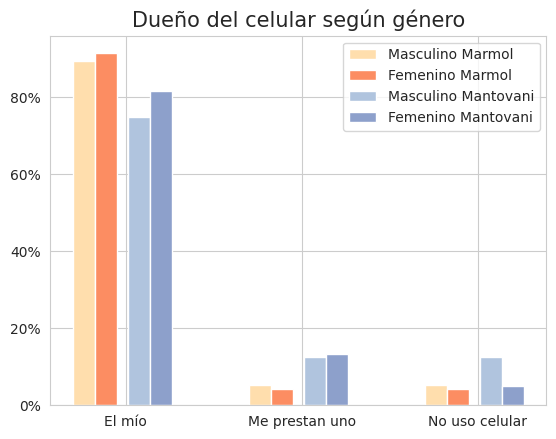

In [24]:
# Dueño del celular según género
data_total = df_fe["dueño_celular"].value_counts(normalize=True).sort_index()

data_marmol_mas = marmol[marmol['genero']=="Masculino"]["dueño_celular"].value_counts(normalize=True).sort_index()
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["dueño_celular"].value_counts(normalize=True).sort_index()

data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["dueño_celular"].value_counts(normalize=True).sort_index()
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["dueño_celular"].value_counts(normalize=True).sort_index()

dfs = [data_marmol_mas, data_marmol_fem, data_mantovani_mas, data_mantovani_fem]

for data in data_total.index:
    for df in dfs:
        if data not in df.index:
            df[data] = 0.0
        df = df.sort_index()

bar_width = 0.25
ticks = [1, 3, 5]

br2 = [x + bar_width for x in ticks]
br3 = [x + bar_width for x in br2]

br4 = [x + 1.5*bar_width for x in br3]
br5 = [x + bar_width for x in br4]
br6 = [x + bar_width for x in br5]

plt.bar(br2,dfs[0], width=bar_width, label = 'Masculino Marmol', color='navajowhite')
plt.bar(br3,dfs[1], width=bar_width, label = 'Femenino Marmol', color='C1')
plt.bar(br4,dfs[2], width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br5,dfs[3], width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Dueño del celular según género", fontsize=15)
ticks = [x + 2.9*bar_width for x in ticks]
plt.xticks(ticks, [id for id in data_total.sort_index().index])
plt.legend()
plt.savefig('dueño_celular_segun_genero.png')

* Porcentajes sobre totales por género
* No parece haber diferencia entre géneros en cuanto a quién es el dueño del celular.
* Cerca de un 10% más de los niñes son dueños de su celular en el Modelo Mármol.

# Uso del celular

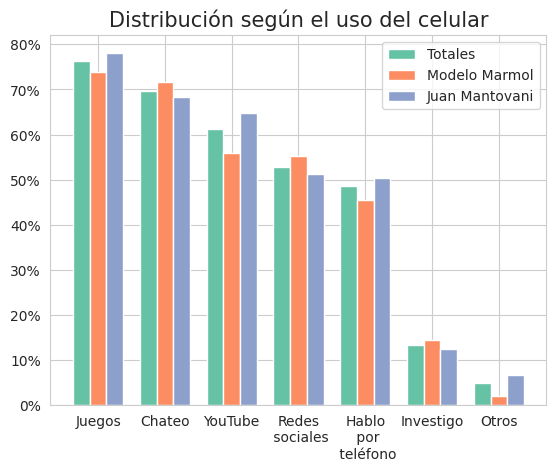

In [25]:
# Distribución según el uso del celular
data_total = df_fe["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)
data_marmol = marmol["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol).sort_values(ascending=False)
data_mantovani = mantovani["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani).sort_values(ascending=False)

otros = ["Hagolatarea", "Programo/Diseño", "Nuncausoelcelular"]

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1)
result = result.rename(columns={0:'Totales',
                                1:'Modelo Marmol',
                                2:'Juan Mantovani'})

result.loc["Otros"] = [0.0]*3

result =result.fillna(0)
for row in otros:
        result.loc['Otros'] += result.loc[row]
        result.drop([row], inplace=True)

bar_width = 0.25

br1 = np.arange(len(result))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

labels = ("Juegos", "Chateo", "YouTube", "Redes\n sociales", \
           "Hablo\n por\n teléfono", "Investigo", "Otros")

plt.bar(br1,result['Totales']       , width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Marmol'] , width=bar_width, label = 'Modelo Marmol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución según el uso del celular", fontsize=15)
plt.xticks([r + bar_width for r in range(len(result))], labels)
plt.legend()
plt.savefig('uso_celular.png')

* Porcentajes sobre totales por colegio
* En esta pregunta se permitían varias respuestas
* En otros se acumulan las resputas "Hagolatarea", "Programo/Diseño", "Nuncausoelcelular" que son seleccionadas menos de un 10% de las veces
* Juegos, y Youtube vuelven a estar entre las más seleccionadas pero ahora Chateo ocupa el segundo lugar, y Usar redes sociales toma más importancia con lo cual notamos diferencias de usos comunes de aplicaciones entre la computadora y el celular.

In [112]:
# Promedio en cantidad de respuestas - Uso del celular
data_total = df_fe["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_marmol = marmol["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani = mantovani["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()

dfs = [data_total,data_marmol,data_mantovani]
labels = ['Totales','Modelo Marmol','Juan Mantovani']

result = pd.DataFrame(data=[dfs], columns=labels)
print("Promedio en cantidad de respuestas - Uso del celular")
result.head()

Promedio en cantidad de respuestas - Uso del celular


,Totales,Modelo Marmol,Juan Mantovani
0,3.268293,3.186207,3.321429


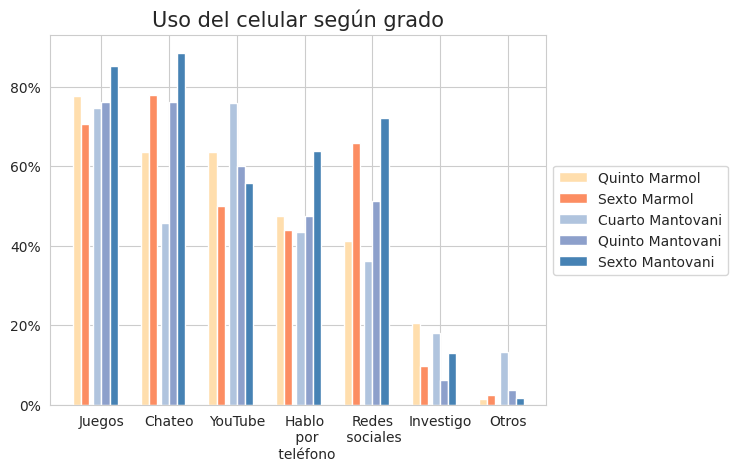

In [31]:
# Uso del celular según grado
data_total = df_fe["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)

data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol_quinto).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol_sexto).sort_values(ascending=False)

data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_cuarto).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_quinto).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_sexto).sort_values(ascending=False)

otros = ["Hagolatarea", "Nuncausoelcelular", "Programo/Diseño"]

dfs = [data_marmol_quinto, data_marmol_sexto, data_mantovani_cuarto, data_mantovani_quinto, data_mantovani_sexto]

result = pd.concat(dfs, axis=1)
result = result.rename(columns={0:'Quinto Marmol',
                                1:'Sexto Marmol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'})

result.loc["Otros"] = [0.0]*5

result =result.fillna(0)
for row in otros:
        result.loc['Otros'] += result.loc[row]
        result.drop([row], inplace=True)

bar_width = 0.12

ticks = np.arange(len(result))

labels = ("Juegos", "Chateo", "YouTube", "Hablo\n por\n teléfono", \
           "Redes\n sociales", "Investigo", "Otros")

br_marmol_quinto = ticks
br_marmol_sexto = [x + bar_width for x in br_marmol_quinto]

br_mantovani_cuarto = [x + 1.5* bar_width for x in br_marmol_sexto]
br_mantovani_quinto = [x + bar_width for x in br_mantovani_cuarto]
br_mantovani_sexto  = [x + bar_width for x in br_mantovani_quinto]

plt.bar(br_marmol_quinto,    result['Quinto Marmol'], width=bar_width, label = 'Quinto Marmol', color='navajowhite')
plt.bar(br_marmol_sexto,     result['Sexto Marmol'], width=bar_width, label = 'Sexto Marmol', color='C1')
plt.bar(br_mantovani_cuarto, result['Cuarto Mantovani'], width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br_mantovani_quinto, result['Quinto Mantovani'], width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br_mantovani_sexto,  result['Sexto Mantovani'], width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Uso del celular según grado", fontsize=15)
ticks = [x + 3*bar_width for x in ticks]
plt.xticks(ticks, labels)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.savefig('uso_celular_segun_grado.png')

* Porcentajes sobre totales por grado
* En esta pregunta se admitían varias respuestas
* En el Modelo Mármol los alumnos de quinto eligen un 10% más la opción Youtube e Investigo que los de Sexto. Los de sexto por su parte Chatean un 15% más, siendo esta su opción más elegida, también usan un 20% más las redes sociales.
* En el Mantovani Chatear, usar redes sociales y hablar por teléfono suben considerablemente de cuarto a Sexto, mientras que Youtube pierde uso.
* Al compararlos, vemos similitudes en los cambios para Chateo, Youtube, Redes sociales e Investigo.

In [113]:
# Promedio en cantidad de respuestas - Uso del celular según grado
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]
labels = ['Quinto Marmol','Sexto Marmol','Cuarto Mantovani','Quinto Mantovani','Sexto Mantovani']

result = pd.DataFrame(data=[dfs], columns=labels)
print("Promedio en cantidad de respuestas - Uso del celular según grado")
result.head()

Promedio en cantidad de respuestas - Uso del celular según grado


,Quinto Marmol,Sexto Marmol,Cuarto Mantovani,Quinto Mantovani,Sexto Mantovani
0,3.15873,3.207317,3.072289,3.2125,3.803279


* Es interesante destacar el promedio de 3.8 respuestas elegidas en el Sexto del Mantovani

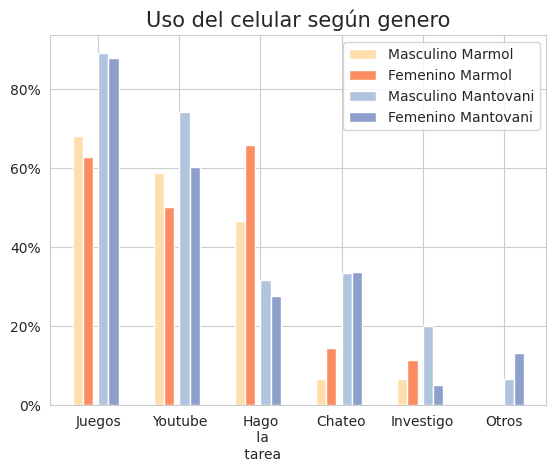

In [27]:
# Uso del celular según género
data_total = df_fe["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)

data_marmol_mas = marmol[marmol['genero']=="Masculino"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol_masc).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol_fem).sort_values(ascending=False)

data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_masc).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_fem).sort_values(ascending=False)

dfs = [data_marmol_mas, data_marmol_fem, data_mantovani_mas, data_mantovani_fem]

result = pd.concat(dfs, axis=1)
result = result.rename(columns={0: "Masculino Marmol", 1: "Femenino Marmol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"})
result.loc["Otros"] = [0.0]*4

otros = ["Escuchomúsica", "Programo/Diseño", "MiroPelis/Seriesporstreaming", "Usoredessociales"]

for row in otros:
        result.loc['Otros'] += result.loc[row]
        result.drop([row], inplace=True)

bar_width = 0.25

ticks = [1, 3, 5, 7, 9, 11]

b1 = ticks
b2 = [x + bar_width for x in b1]
b3 = [x + 1.5* bar_width for x in b2]
b4 = [x + bar_width for x in b3]

plt.bar(b1,result["Masculino Marmol"]   , width=bar_width, label = 'Masculino Marmol', color='navajowhite')
plt.bar(b2,result["Femenino Marmol"]    , width=bar_width, label = 'Femenino Marmol', color='C1')
plt.bar(b3,result["Masculino Mantovani"], width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(b4,result["Femenino Mantovani"] , width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Uso del celular según genero", fontsize=15)

labels = ["Juegos", "Youtube", "Hago\n la\n tarea", "Chateo", "Investigo", "Otros"]
ticks = [x + 2*bar_width for x in ticks]
plt.xticks(ticks, labels)
plt.legend(loc='upper right')
plt.savefig('uso_celular_segun_genero.png')


* Porcentajes sobre totales de género por colegio (la suma de los géneros da el total de alumnos por colegio)
* En esta pregunta se podían seleccionar varias respuestas
* Se ignoró el género Otros por representar un porcentaje muy bajo de la muestra (6 alumnos en total)
* Las opciones "Escuchomúsica", "Programo/Diseño", "MiroPelis/Seriesporstreaming", "Usoredessociales" eran seleccionadas en promedio menos del  5% de las veces. Por este motivo se agruparon en la resputas "Otros"
* En el Modelo Mármol las chicas seleccionan un 20% más la opción "Hago la tarea" y un 5% más la opción "Chateo"
* En el Mantovani los chicos seleccionan un 10% más la opción "Miro videos en youtube" y más de un 15% más la opción "Inverstigo"

In [115]:
# Promedio en cantidad de respuestas - Uso del celular según género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]
labels = ["Masculino Marmol","Femenino Marmol","Masculino Mantovani","Femenino Mantovani"]

result = pd.DataFrame(data=[dfs], columns=labels)
print("Promedio en cantidad de respuestas - Uso del celular según género")
result.head()

Promedio en cantidad de respuestas - Uso del celular según género


,Masculino Marmol,Femenino Marmol,Masculino Mantovani,Femenino Mantovani
0,1.88,2.057143,2.55,2.27551


* Notable la diferencia en cantidad de usos de celular entre varones de ambos colegios